In [1]:
# ==============================================================================# ✅ Install dependencies
!pip install -q -U google-genai

print("✅ Dependencies installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.1/259.1 kB 21.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.3 which is incompatible.
✅ Dependencies installed successfully!


In [2]:
# ✅ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [3]:
# ✅ Load Gemini API key from Colab Secrets
from google.colab import userdata
import os

print("Loading Gemini API key from Colab Secrets...\n")

GEMINI_API_KEY = None

try:
    GEMINI_API_KEY = userdata.get("Gemini-API-Key")

    if GEMINI_API_KEY:
        os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
        print("✅ Gemini API key loaded")
    else:
        print("❌ Gemini API key not found!")
        print("📝 Please add 'Gemini-API-Key' to Colab Secrets (🔑 icon)")

except Exception as e:
    print(f"❌ Error loading Gemini API key: {e}")

Loading Gemini API key from Colab Secrets...

✅ Gemini API key loaded


In [4]:
# ✅ Import libraries
import os
import json
import time
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Gemini API
try:
    import google.genai as genai
    from google.genai import types
    print("✅ Google GenAI imported successfully")
except ImportError:
    print("❌ google-genai package not found - please re-run previous cell")

print("✅ All libraries imported!")

✅ Google GenAI imported successfully
✅ All libraries imported!


In [5]:
# ============================================================================
# 📂 DATASET PATH + AUTOMATIC GROUND TRUTH FROM SUBFOLDERS
# ============================================================================

from pathlib import Path
import os
from collections import Counter

folder_path = "/content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Labeled-Data-NN/Journal-version-data/Test-for-VLM-Vehicle-type"

# Expected structure:

# IMPORTANT:
# These class labels and descriptions are intentionally identical
# to the Claude notebook for an apples-to-apples comparison.
class_prompts_dict = {
    "Personal-Commuter-Vehicle": "A personal commuter vehicle such as a car, SUV, pickup truck, or passenger van at a railroad crossing",
    "Bus": "A bus at a railroad crossing",
    "Commercial-Truck-Van-and-Service-Vehicle": "A commercial truck, commercial van, or service vehicle at a railroad crossing",
    "Emergency-or-Utility-Vehicle": "An emergency or utility vehicle at a railroad crossing",
    "Multi-Class-Vehicles": "Two or more different vehicle types simultaneously at a railroad crossing"
}
VALID_CLASSES = list(class_prompts_dict.keys())

# Verify main folder
if os.path.exists(folder_path):
    print(f"✅ Dataset folder found: {folder_path}")
else:
    print(f"❌ Dataset folder not found: {folder_path}")

# Verify class folders
for class_name in VALID_CLASSES:
    class_folder = os.path.join(folder_path, class_name)

    if os.path.exists(class_folder):
        print(f"✅ Found class folder: {class_name}")
    else:
        print(f"⚠️ Missing class folder: {class_name}")



✅ Dataset folder found: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Labeled-Data-NN/Journal-version-data/Test-for-VLM-Vehicle-type
✅ Found class folder: Personal-Commuter-Vehicle
✅ Found class folder: Bus
✅ Found class folder: Commercial-Truck-Van-and-Service-Vehicle
✅ Found class folder: Emergency-or-Utility-Vehicle
✅ Found class folder: Multi-Class-Vehicles


In [6]:
# ============================================================================
# LOAD IMAGES + CREATE GROUND TRUTH
# ============================================================================

def load_images_with_ground_truth(
    base_folder,
    class_names,
    image_extensions=(".jpg", ".jpeg", ".png")
):
    """
    Load images from class-specific subfolders and automatically
    generate ground-truth labels from folder names.

    Returns:
        image_paths: List of all image paths
        ground_truth_labels: Dict {full_image_path: true_class}
    """

    image_paths = []
    ground_truth_labels = {}

    for class_name in class_names:

        class_folder = Path(base_folder) / class_name

        if not class_folder.exists():
            print(f"⚠️ Class folder not found: {class_folder}")
            continue

        for img_file in class_folder.iterdir():

            if (
                img_file.is_file()
                and img_file.suffix.lower() in image_extensions
            ):

                img_path = str(img_file)

                image_paths.append(img_path)

                # Folder name becomes true class
                ground_truth_labels[img_path] = class_name

    image_paths = sorted(image_paths)

    return image_paths, ground_truth_labels


# Load dataset
image_paths, ground_truth_labels = load_images_with_ground_truth(
    folder_path,
    VALID_CLASSES
)

print("\n" + "=" * 80)
print("📊 DATASET SUMMARY")
print("=" * 80)

print(f"Total images found: {len(image_paths)}")

ground_truth_distribution = Counter(
    ground_truth_labels.values()
)

print("\nGround Truth Distribution:")

for class_name in VALID_CLASSES:
    print(
        f"  • {class_name}: "
        f"{ground_truth_distribution.get(class_name, 0)}"
    )

# Safety check
if len(image_paths) != 106:
    print(
        f"\n⚠️ WARNING: Expected 106 images, "
        f"but found {len(image_paths)}."
    )
else:
    print("\n✅ Exactly 106 images found.")

# Show sample
print("\n📋 Sample images:")

for img_path in image_paths[:5]:
    print(
        f"  {os.path.basename(img_path)} "
        f"→ {ground_truth_labels[img_path]}"
    )



📊 DATASET SUMMARY
Total images found: 106

Ground Truth Distribution:
  • Personal-Commuter-Vehicle: 21
  • Bus: 15
  • Commercial-Truck-Van-and-Service-Vehicle: 30
  • Emergency-or-Utility-Vehicle: 16
  • Multi-Class-Vehicles: 24

✅ Exactly 106 images found.

📋 Sample images:
  Screenshot 2025-04-24 093014.jpg → Bus
  Screenshot 2025-04-29 071827.jpg → Bus
  Screenshot 2025-05-02 124102.jpg → Bus
  Screenshot 2025-05-02 124817.jpg → Bus
  Screenshot 2025-05-07 170054.jpg → Bus


In [7]:
# ✅ Initialize Gemini API client
gemini_client = None

if GEMINI_API_KEY:
    try:
        gemini_client = genai.Client(api_key=GEMINI_API_KEY)
        print("✅ Gemini API initialized")
    except Exception as e:
        print(f"❌ Gemini initialization failed: {e}")
else:
    print("❌ Gemini API key unavailable - client not initialized")

✅ Gemini API initialized


In [8]:
def zero_shot_predict_gemini(
    image_path,
    class_prompts_dict,
    show_image=False,
    model_name="gemini-3.5-flash",
    max_retries=3
):
    """
    Performs zero-shot multiclass classification using gemini-3.5-flash.

    """

    if not gemini_client:
        return None, 0.0, {}, {}

    try:
        # ------------------------------------------------------------
        # 1. Load image
        # ------------------------------------------------------------
        image = Image.open(image_path).convert("RGB")

        # ------------------------------------------------------------
        # 2. Build multiclass prompt
        # IMPORTANT: Semantic instructions mirror the Claude notebook.
        # ------------------------------------------------------------
        class_text = "\n".join(
            [
                f"{label}: {description}"
                for label, description
                in class_prompts_dict.items()
            ]
        )

        valid_classes = list(class_prompts_dict.keys())

        prompt_text = f"""
You are a zero-shot image classifier for railroad-crossing scenes.

Classify the provided image into EXACTLY ONE of the following classes:

{class_text}

Instructions:
- Select only one class.
- Use the class descriptions above to determine the best matching class.
- Return ONLY the class label.
- Do not provide explanations.
- Do not return Yes/No.
- Do not return multiple classes.

Valid outputs are exactly:
{", ".join(class_prompts_dict.keys())}

"""

        # ------------------------------------------------------------
        # 3. Gemini-specific response schema
        # A direct string enum is the closest structured-output analogue
        # to Claude's one-label text response.
        # ------------------------------------------------------------
        response_schema = {
            "type": "string",
            "enum": valid_classes
        }

        last_error = None

        # ------------------------------------------------------------
        # 4. Call Gemini API
        # Retry only technical/format failures, never a class prediction.
        # ------------------------------------------------------------
        for attempt in range(1, max_retries + 1):

            try:
                response = gemini_client.models.generate_content(
                    model=model_name,
                    contents=[
                        prompt_text,
                        image
                    ],
                    config=types.GenerateContentConfig(
                        # Gemini 3.5 Flash defaults to medium thinking.
                        # Minimal thinking is more appropriate for a simple
                        # five-class zero-shot classification task.
                        thinking_config=types.ThinkingConfig(
                            thinking_level="minimal"
                        ),
                        max_output_tokens=300,
                        response_mime_type="application/json",
                        response_json_schema=response_schema
                    )
                )

                # ----------------------------------------------------
                # 5. Extract response text
                # ----------------------------------------------------
                output_text = ""

                try:
                    if response.text:
                        output_text = response.text.strip()
                except Exception:
                    output_text = ""

                finish_reason = None

                if response.candidates and len(response.candidates) > 0:
                    finish_reason = response.candidates[0].finish_reason

                if not output_text:
                    last_error = (
                        f"Empty response "
                        f"(finish_reason={finish_reason})"
                    )

                    if attempt < max_retries:
                        print(
                            f"⚠️ Gemini technical response failure: "
                            f"{last_error}. "
                            f"Retrying {attempt + 1}/{max_retries}..."
                        )
                        time.sleep(3 * attempt)
                        continue

                    print(f"⚠️ Gemini technical response failure: {last_error}")

                    return None, 0.0, {}, {
                        "raw_response": "",
                        "finish_reason": str(finish_reason),
                        "attempts": attempt,
                        "model": model_name
                    }

                # ----------------------------------------------------
                # 6. Parse the JSON string enum
                # Expected response example: "VEHICLE"
                # ----------------------------------------------------
                try:
                    predicted_class = json.loads(output_text)
                except json.JSONDecodeError:
                    # Conservative fallback: exact class-label text only.
                    normalized = output_text.strip().strip('"').strip("'")
                    predicted_class = None

                    for class_name in valid_classes:
                        if normalized.lower() == class_name.lower():
                            predicted_class = class_name
                            break

                # ----------------------------------------------------
                # 7. Validate returned class
                # ----------------------------------------------------
                if predicted_class in valid_classes:
                    class_scores = {
                        class_name:
                            1.0 if class_name == predicted_class else 0.0
                        for class_name in valid_classes
                    }

                    # Compatibility placeholder only; not model confidence.
                    predicted_confidence = 1.0

                    response_dict = {
                        "raw_response": output_text,
                        "predicted_class": predicted_class,
                        "finish_reason": str(finish_reason),
                        "attempts": attempt,
                        "model": model_name
                    }

                    if show_image:
                        plt.imshow(image)
                        plt.axis("off")
                        plt.title(
                            f"Gemini 3.5 Flash Prediction: "
                            f"{predicted_class}"
                        )
                        plt.show()

                        print(
                            f"Predicted Class: "
                            f"{predicted_class}"
                        )

                    return (
                        predicted_class,
                        predicted_confidence,
                        class_scores,
                        response_dict
                    )

                # Invalid/malformed output = technical format failure.
                last_error = f"Could not parse Gemini response: {output_text}"

                if attempt < max_retries:
                    print(
                        f"⚠️ {last_error}. "
                        f"Retrying {attempt + 1}/{max_retries}..."
                    )
                    time.sleep(3 * attempt)
                    continue

                print(f"⚠️ {last_error}")

                return None, 0.0, {}, {
                    "raw_response": output_text,
                    "finish_reason": str(finish_reason),
                    "attempts": attempt,
                    "model": model_name
                }

            except Exception as e:
                last_error = str(e)

                if attempt < max_retries:
                    print(
                        f"⚠️ Gemini API error: {e}. "
                        f"Retrying {attempt + 1}/{max_retries}..."
                    )
                    time.sleep(5 * attempt)
                    continue

                print(f"❌ Gemini error after {max_retries} attempts: {e}")

                return None, 0.0, {}, {
                    "error": str(e),
                    "attempts": attempt,
                    "model": model_name
                }

    except Exception as e:
        print(f"❌ Gemini error: {e}")
        return None, 0.0, {}, {}

In [9]:
def evaluate_model(
    model_name,
    predict_fn,
    image_paths,
    class_prompts_dict,
    delay_seconds=2
):
    """
    Evaluate a model on all images.

    Args:
        model_name: Name of the model
        predict_fn: Prediction function
        image_paths: List of image paths
        class_prompts_dict: Dictionary mapping class labels to descriptions

    Returns:
        tuple: (summary_dict, results_dataframe)
    """

    print(f"\n🔎 Evaluating {model_name}...")
    print(f"{'─' * 80}")

    predictions = []
    confidences = []
    errors = 0

    # ------------------------------------------------------------
    # Run predictions
    # ------------------------------------------------------------
    for i, img_path in enumerate(image_paths, 1):

        try:
            pred, conf, _, _ = predict_fn(
                img_path,
                class_prompts_dict
            )

            if pred is None:
                pred = "ERROR"
                conf = 0.0
                errors += 1

            predictions.append(pred)
            confidences.append(
                conf if conf else 0.0
            )

            # Progress — same cadence as Claude notebook
            if i % 50 == 0 or i == len(image_paths):
                valid_so_far = len(predictions) - errors
                print(
                    f"  ✅ {i}/{len(image_paths)} processed "
                    f"| Valid: {valid_so_far} "
                    f"| Errors: {errors}"
                )

            # Provide throttling safeguard
            if delay_seconds and i < len(image_paths):
                time.sleep(delay_seconds)

        except Exception as e:
            predictions.append("ERROR")
            confidences.append(0.0)
            errors += 1

    # ------------------------------------------------------------
    # Create results DataFrame
    # ------------------------------------------------------------
    results_df = pd.DataFrame({
        "Model": [model_name] * len(image_paths),

        "Image": [
            os.path.basename(p)
            for p in image_paths
        ],

        "Image_Path": image_paths,

        "Prediction": predictions,

        "Confidence": confidences
    })

    # ------------------------------------------------------------
    # Valid prediction statistics
    # ------------------------------------------------------------
    successful = (
        results_df["Prediction"] != "ERROR"
    ).sum()

    success_rate = (
        successful / len(image_paths) * 100
        if len(image_paths) > 0
        else 0
    )

    # ------------------------------------------------------------
    # Prediction distribution
    # ------------------------------------------------------------
    pred_counts = (
        results_df["Prediction"]
        .value_counts()
    )

    print(f"\n✅ {model_name} Results:")

    print(
        f"  • Valid Predictions: "
        f"{successful}/{len(image_paths)} "
        f"({success_rate:.1f}%)"
    )

    if successful != len(image_paths):
        print(
            f"  ⚠️ Technical/API failures remain: "
            f"{len(image_paths) - successful}. "
            f"For the final paper comparison, rerun failed cases "
            f"until evaluation coverage is 106/106."
        )

    print("  • Prediction distribution:")

    for pred, count in pred_counts.items():

        if pred != "ERROR":

            pct = (
                count / successful * 100
                if successful > 0
                else 0
            )

            print(
                f"    - {pred}: "
                f"{count} ({pct:.1f}%)"
            )

    # ------------------------------------------------------------
    # Summary
    # ------------------------------------------------------------
    summary = {
        "Model": model_name,
        "Total_Images": len(image_paths),
        "Valid_Predictions": successful,
        "Parsing_Success_Rate": f"{success_rate:.1f}%"
    }

    return summary, results_df


In [10]:
# ✅ Initialize results storage
all_summaries = []
all_results = {}
print("✅ Results storage initialized")

✅ Results storage initialized


In [11]:
# ============================================================================
# Gemini 3.5 Flash
# ============================================================================
if gemini_client:
    print("\n" + "="*80)
    print("Evaluating gemini-3.5-flash...")
    print("="*80)

    summary_gemini, results_gemini = evaluate_model(
        model_name="Gemini 3.5 Flash",
        predict_fn=zero_shot_predict_gemini,
        image_paths=image_paths,
        class_prompts_dict=class_prompts_dict
    )

    all_summaries.append(summary_gemini)
    all_results["gemini-3.5-flash"] = results_gemini
    print(f"\n✅ Summary: {summary_gemini}")
else:
    print("❌ Gemini not initialized - skipping evaluation")


Evaluating gemini-3.5-flash...

🔎 Evaluating Gemini 3.5 Flash...
────────────────────────────────────────────────────────────────────────────────


  ✅ 50/106 processed | Valid: 50 | Errors: 0
  ✅ 100/106 processed | Valid: 100 | Errors: 0
  ✅ 106/106 processed | Valid: 106 | Errors: 0

✅ Gemini 3.5 Flash Results:
  • Valid Predictions: 106/106 (100.0%)
  • Prediction distribution:
    - Commercial-Truck-Van-and-Service-Vehicle: 43 (40.6%)
    - Multi-Class-Vehicles: 24 (22.6%)
    - Personal-Commuter-Vehicle: 22 (20.8%)
    - Bus: 15 (14.2%)
    - Emergency-or-Utility-Vehicle: 2 (1.9%)

✅ Summary: {'Model': 'Gemini 3.5 Flash', 'Total_Images': 106, 'Valid_Predictions': np.int64(106), 'Parsing_Success_Rate': '100.0%'}


In [12]:
# ============================================================================
# 📈 CLASSIFICATION METRICS FUNCTION
# ============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

def prepare_results_with_metrics(
    results_df,
    ground_truth_labels,
    class_prompts_dict
):
    df = results_df.copy()
    classes = list(class_prompts_dict.keys())

    # Ground truth and correctness
    df["Ground_Truth"] = df["Image_Path"].map(ground_truth_labels)
    df["Correct"] = df["Prediction"] == df["Ground_Truth"]

    # Valid predictions only
    valid_df = df[
        (df["Prediction"] != "ERROR") &
        (df["Ground_Truth"].notna())
    ].copy()

    if valid_df.empty:
        return df, None

    y_true = valid_df["Ground_Truth"].tolist()
    y_pred = valid_df["Prediction"].tolist()

    # Overall accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Per-class metrics
    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=classes,
            zero_division=0
        )
    )

    # Classification report contains macro + weighted metrics
    report = classification_report(
        y_true,
        y_pred,
        labels=classes,
        target_names=classes,
        output_dict=True,
        zero_division=0
    )

    precision_dict = dict(zip(classes, precision))
    recall_dict = dict(zip(classes, recall))
    f1_dict = dict(zip(classes, f1))
    support_dict = dict(zip(classes, support))

    # Add metrics to detailed results
    df["Class_Precision"] = df["Ground_Truth"].map(precision_dict)
    df["Class_Recall"] = df["Ground_Truth"].map(recall_dict)
    df["Class_F1"] = df["Ground_Truth"].map(f1_dict)
    df["Overall_Accuracy"] = accuracy

    metrics = {
        "accuracy": accuracy,

        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],

        "weighted_precision": report["weighted avg"]["precision"],
        "weighted_recall": report["weighted avg"]["recall"],
        "weighted_f1": report["weighted avg"]["f1-score"],

        "classes": classes,
        "precision_per_class": precision_dict,
        "recall_per_class": recall_dict,
        "f1_per_class": f1_dict,
        "support": support_dict,

        "true_labels": y_true,
        "pred_labels": y_pred,

        "confusion_matrix": confusion_matrix(
            y_true,
            y_pred,
            labels=classes
        )
    }

    return df, metrics

In [13]:
# ============================================================================
# 💾 EXPORT DETAILED PREDICTIONS + PRINT CLASSIFICATION REPORT
# ============================================================================

if all_results:

    combined_results = []
    model_metrics = {}

    for model_name, results_df in all_results.items():

        enriched_df, metrics = prepare_results_with_metrics(
            results_df,
            ground_truth_labels,
            class_prompts_dict
        )

        combined_results.append(enriched_df)
        model_metrics[model_name] = metrics

        # Full classification report
        if metrics is not None:

            print("\n" + "=" * 80)
            print(f"📊 CLASSIFICATION REPORT — {model_name}")
            print("=" * 80)

            print(
                classification_report(
                    metrics["true_labels"],
                    metrics["pred_labels"],
                    labels=metrics["classes"],
                    target_names=metrics["classes"],
                    zero_division=0,
                    digits=4
                )
            )

    # Combine all predictions
    all_predictions = pd.concat(
        combined_results,
        ignore_index=True
    )

    # Save CSV
    output_path = (
        "/content/"
        "vehicle_type_gemini_predictions_with_metrics.csv"
    )

    all_predictions.to_csv(
        output_path,
        index=False
    )

    print(f"\n✅ Saved to: {output_path}")

    # Preview
    display_columns = [
        "Model",
        "Image",
        "Ground_Truth",
        "Prediction",
        "Correct",
        "Class_Precision",
        "Class_Recall",
        "Class_F1",
        "Overall_Accuracy"
    ]

    print(
        all_predictions[display_columns]
        .head(10)
        .to_string(index=False)
    )

else:
    print("⚠️ No results to export")


📊 CLASSIFICATION REPORT — gemini-3.5-flash
                                          precision    recall  f1-score   support

               Personal-Commuter-Vehicle     0.9545    1.0000    0.9767        21
                                     Bus     1.0000    1.0000    1.0000        15
Commercial-Truck-Van-and-Service-Vehicle     0.6744    0.9667    0.7945        30
            Emergency-or-Utility-Vehicle     1.0000    0.1250    0.2222        16
                    Multi-Class-Vehicles     0.9583    0.9583    0.9583        24

                                accuracy                         0.8491       106
                               macro avg     0.9175    0.8100    0.7904       106
                            weighted avg     0.8894    0.8491    0.8104       106


✅ Saved to: /content/vehicle_type_gemini_predictions_with_metrics.csv
           Model                            Image Ground_Truth Prediction  Correct  Class_Precision  Class_Recall  Class_F1  Overall_Accuracy
Ge

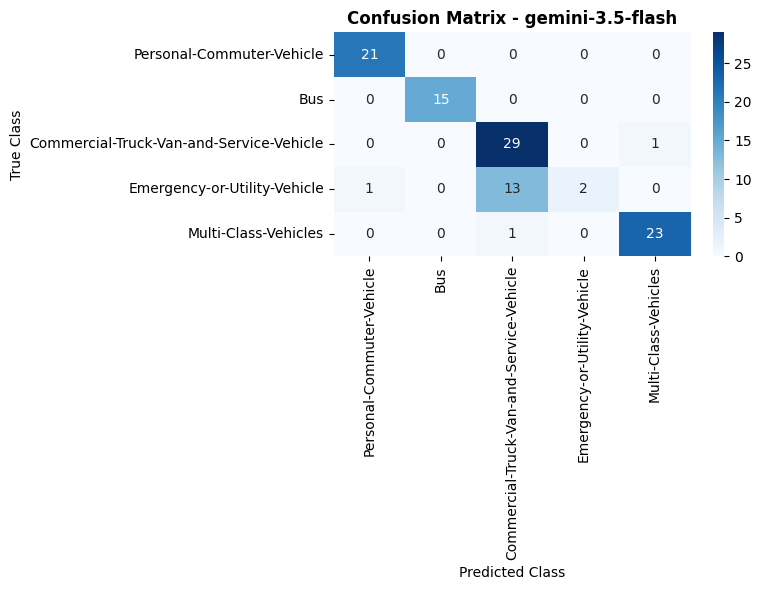

In [14]:
# ============================================================================
# 📊 CONFUSION MATRIX VISUALIZATION
# ============================================================================

if all_results:

    for model_name, metrics in model_metrics.items():

        if metrics is None:
            continue

        plt.figure(figsize=(8, 6))

        sns.heatmap(
            metrics["confusion_matrix"],
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=metrics["classes"],
            yticklabels=metrics["classes"]
        )

        plt.title(
            f"Confusion Matrix - {model_name}",
            fontweight="bold"
        )

        plt.xlabel("Predicted Class")
        plt.ylabel("True Class")

        plt.tight_layout()
        plt.show()

else:
    print(
        "⚠️ No results available for visualization"
    )


In [15]:
# ============================================================================
# 🖼️ SEQUENTIAL IMAGE-BY-IMAGE PREDICTION REVIEW
# 106 Images → 5 Batches × 44 Images
# ============================================================================

import os
import math
import matplotlib.pyplot as plt
from PIL import Image


# ============================================================================
# SETTINGS
# ============================================================================

BATCH_SIZE = 44
NUM_BATCHES = 5

# Number of images per row
IMAGES_PER_ROW = 4


# ============================================================================
# VERIFY RESULTS
# ============================================================================

if "all_predictions" not in globals():

    print(
        "❌ all_predictions not found.\n"
        "Run the detailed prediction export/metrics cell first."
    )

else:

    # ------------------------------------------------------------------------
    # Select the model results
    # ------------------------------------------------------------------------
    model_names = all_predictions["Model"].unique()

    print("=" * 80)
    print("🖼️ SEQUENTIAL PREDICTION REVIEW")
    print("=" * 80)

    print(
        f"Models available: "
        f"{', '.join(model_names)}"
    )

    for model_name in model_names:

        print(
            f"\n🤖 Reviewing predictions for: "
            f"{model_name}"
        )

        # --------------------------------------------------------------------
        # Get current model results
        # --------------------------------------------------------------------
        model_df = (
            all_predictions[
                all_predictions["Model"] == model_name
            ]
            .copy()
            .reset_index(drop=True)
        )

        total_images = len(model_df)

        print(
            f"Total images available: "
            f"{total_images}"
        )

        # Safety check
        if total_images != 106:

            print(
                f"⚠️ Expected 106 images, "
                f"but found {total_images}."
            )

        # ====================================================================
        # CREATE 5 SEQUENTIAL BATCHES
        # ====================================================================

        for batch_num in range(NUM_BATCHES):

            start_idx = (
                batch_num * BATCH_SIZE
            )

            end_idx = min(
                start_idx + BATCH_SIZE,
                total_images
            )

            batch_df = model_df.iloc[
                start_idx:end_idx
            ]

            if len(batch_df) == 0:
                continue

            print("\n" + "=" * 80)

            print(
                f"📦 BATCH {batch_num + 1}/{NUM_BATCHES}"
            )

            print(
                f"Images {start_idx + 1}–{end_idx}"
            )

            print("=" * 80)

            # ----------------------------------------------------------------
            # Plot layout
            # ----------------------------------------------------------------
            n_images = len(batch_df)

            n_cols = IMAGES_PER_ROW

            n_rows = math.ceil(
                n_images / n_cols
            )

            fig, axes = plt.subplots(
                n_rows,
                n_cols,
                figsize=(
                    4 * n_cols,
                    3.6 * n_rows
                )
            )

            axes = axes.flatten()

            # ================================================================
            # DISPLAY EACH IMAGE
            # ================================================================

            for plot_idx, (_, row) in enumerate(
                batch_df.iterrows()
            ):

                ax = axes[plot_idx]

                img_path = row["Image_Path"]

                ground_truth = row[
                    "Ground_Truth"
                ]

                prediction = row[
                    "Prediction"
                ]

                correct = (
                    ground_truth
                    == prediction
                )

                try:

                    image = Image.open(
                        img_path
                    ).convert("RGB")

                    ax.imshow(image)

                except Exception as e:

                    ax.text(
                        0.5,
                        0.5,
                        "Image\nUnavailable",
                        ha="center",
                        va="center"
                    )

                ax.axis("off")

                # ------------------------------------------------------------
                # Image sequence number
                # ------------------------------------------------------------
                sequence_number = (
                    start_idx
                    + plot_idx
                    + 1
                )

                result_symbol = (
                    "✓"
                    if correct
                    else "✗"
                )

                # ------------------------------------------------------------
                # Title
                # ------------------------------------------------------------
                ax.set_title(
                    f"#{sequence_number} {result_symbol}\n"
                    f"True: {ground_truth}\n"
                    f"Pred: {prediction}",
                    fontsize=9,
                    fontweight="bold"
                )

            # ----------------------------------------------------------------
            # Hide unused subplot spaces
            # ----------------------------------------------------------------
            for empty_idx in range(
                n_images,
                len(axes)
            ):

                axes[
                    empty_idx
                ].axis("off")

            # ----------------------------------------------------------------
            # Main batch title
            # ----------------------------------------------------------------
            plt.suptitle(
                f"{model_name}\n"
                f"Batch {batch_num + 1}: "
                f"Images {start_idx + 1}–{end_idx}",
                fontsize=16,
                fontweight="bold",
                y=1.002
            )

            plt.tight_layout()

            plt.show()

    print(
        "\n✅ Sequential image review complete!"
    )


Output hidden; open in https://colab.research.google.com to view.


💰 API COST REPORT

🤖 gemini-3.5-flash
--------------------------------------------------------------------------------
Images Processed:        106
Successful Predictions:  106/106 (100.0%)

💵 NORMALIZED ESTIMATED API COST BREAKDOWN
  Total Input Tokens:    48,760
  Total Output Tokens:   15,900
  Total Tokens:          64,660
  Input Cost:            $0.0731
  Output Cost:           $0.1431
  ➜ TOTAL COST:          $0.2162
  Cost per Image:        $0.002040


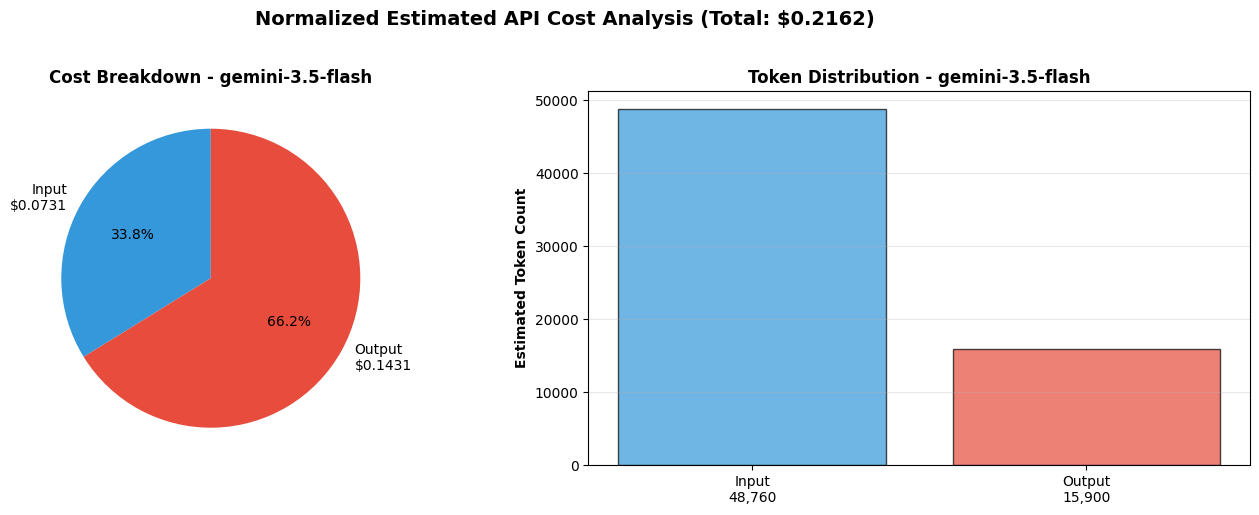


✅ API Cost Analysis Complete!


In [16]:
# ============================================================================
# 💰 API COST ANALYSIS
# ============================================================================

import matplotlib.pyplot as plt


# ============================================================================
# 1️⃣ MODEL PRICING
# ============================================================================

# Gemini 3.5 Flash STANDARD PAID API pricing:
# Input:  $1.50 per 1M tokens
# Output: $9.00 per 1M tokens (including thinking tokens)
#
# Converted to cost per 1K tokens:
MODEL_PRICING = {
    "input_cost_per_1k": 0.00150,
    "output_cost_per_1k": 0.00900
}


# ============================================================================
# 2️⃣ API COST CALCULATION FUNCTION
# ============================================================================

def calculate_api_costs(
    results_df,
    num_images,
    avg_input_tokens=460,
    avg_output_tokens=150
):
    """
    Estimate total API usage cost using the SAME normalized token
    assumptions as the Claude notebook for direct cost comparability.

    NOTE:
    These are normalized estimates, not actual billed token counts.
    """

    if num_images == 0:

        return {
            "num_images": 0,
            "total_input_tokens": 0,
            "total_output_tokens": 0,
            "total_tokens": 0,
            "input_cost": 0,
            "output_cost": 0,
            "total_cost": 0,
            "cost_per_image": 0
        }

    # ------------------------------------------------------------------------
    # Estimated Token Usage
    # ------------------------------------------------------------------------
    total_input_tokens = (
        num_images * avg_input_tokens
    )

    total_output_tokens = (
        num_images * avg_output_tokens
    )

    # ------------------------------------------------------------------------
    # Cost Calculation
    # ------------------------------------------------------------------------
    input_cost = (
        total_input_tokens / 1000
    ) * MODEL_PRICING["input_cost_per_1k"]

    output_cost = (
        total_output_tokens / 1000
    ) * MODEL_PRICING["output_cost_per_1k"]

    total_cost = (
        input_cost + output_cost
    )

    cost_per_image = (
        total_cost / num_images
    )

    return {

        "num_images":
            num_images,

        "total_input_tokens":
            total_input_tokens,

        "total_output_tokens":
            total_output_tokens,

        "total_tokens":
            total_input_tokens + total_output_tokens,

        "input_cost":
            input_cost,

        "output_cost":
            output_cost,

        "total_cost":
            total_cost,

        "cost_per_image":
            cost_per_image
    }


# ============================================================================
# 3️⃣ CALCULATE & PRINT API COST REPORT
# ============================================================================

if all_results:

    print("\n" + "=" * 80)
    print("💰 API COST REPORT")
    print("=" * 80)

    for model_name, results_df in all_results.items():

        num_images = len(results_df)

        num_successful = len(
            results_df[
                results_df["Prediction"] != "ERROR"
            ]
        )

        # --------------------------------------------------------------------
        # Calculate normalized estimated API cost
        # --------------------------------------------------------------------
        cost_info = calculate_api_costs(
            results_df,
            num_images
        )

        print(f"\n🤖 {model_name}")
        print("-" * 80)

        print(
            f"Images Processed:        "
            f"{cost_info['num_images']}"
        )

        if num_images > 0:

            success_rate = (
                num_successful /
                num_images *
                100
            )

        else:
            success_rate = 0

        print(
            f"Successful Predictions:  "
            f"{num_successful}/{num_images} "
            f"({success_rate:.1f}%)"
        )

        print("\n💵 NORMALIZED ESTIMATED API COST BREAKDOWN")

        print(
            f"  Total Input Tokens:    "
            f"{cost_info['total_input_tokens']:,}"
        )

        print(
            f"  Total Output Tokens:   "
            f"{cost_info['total_output_tokens']:,}"
        )

        print(
            f"  Total Tokens:          "
            f"{cost_info['total_tokens']:,}"
        )

        print(
            f"  Input Cost:            "
            f"${cost_info['input_cost']:.4f}"
        )

        print(
            f"  Output Cost:           "
            f"${cost_info['output_cost']:.4f}"
        )

        print(
            f"  ➜ TOTAL COST:          "
            f"${cost_info['total_cost']:.4f}"
        )

        print(
            f"  Cost per Image:        "
            f"${cost_info['cost_per_image']:.6f}"
        )

        # --------------------------------------------------------------------
        # Cost Visualization
        # --------------------------------------------------------------------
        fig, (ax1, ax2) = plt.subplots(
            1,
            2,
            figsize=(14, 5)
        )

        # Cost breakdown pie chart
        costs = [
            cost_info["input_cost"],
            cost_info["output_cost"]
        ]

        labels = [
            f"Input\n${cost_info['input_cost']:.4f}",
            f"Output\n${cost_info['output_cost']:.4f}"
        ]

        colors = [
            "#3498db",
            "#e74c3c"
        ]

        ax1.pie(
            costs,
            labels=labels,
            autopct="%1.1f%%",
            colors=colors,
            startangle=90
        )

        ax1.set_title(
            f"Cost Breakdown - {model_name}",
            fontweight="bold",
            fontsize=12
        )

        # --------------------------------------------------------------------
        # Token Breakdown
        # --------------------------------------------------------------------
        tokens = [
            cost_info["total_input_tokens"],
            cost_info["total_output_tokens"]
        ]

        token_labels = [
            f"Input\n{cost_info['total_input_tokens']:,}",
            f"Output\n{cost_info['total_output_tokens']:,}"
        ]

        ax2.bar(
            token_labels,
            tokens,
            color=colors,
            edgecolor="black",
            alpha=0.7
        )

        ax2.set_ylabel(
            "Estimated Token Count",
            fontweight="bold"
        )

        ax2.set_title(
            f"Token Distribution - {model_name}",
            fontweight="bold",
            fontsize=12
        )

        ax2.grid(
            axis="y",
            alpha=0.3
        )

        plt.suptitle(
            f"Normalized Estimated API Cost Analysis "
            f"(Total: ${cost_info['total_cost']:.4f})",
            fontsize=14,
            fontweight="bold",
            y=1.02
        )

        plt.tight_layout()
        plt.show()


    print("\n" + "=" * 80)
    print("✅ API Cost Analysis Complete!")
    print("=" * 80)

